In [22]:

import os
import math
import time
import random
import json
from typing import Tuple, Dict, List

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset


import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.6.0+cu124
torchvision: 0.21.0+cu124


In [23]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True
DATA_DIR = "./data"

BATCH_SIZE = 64
EPOCHS_CNN = 3 if FAST_MODE else 10
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT = 3 if FAST_MODE else 8

ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

SVHN_MEAN = (0.4377, 0.4438, 0.4728)
SVHN_STD = (0.1980, 0.2010, 0.1970)

Device: cuda


In [24]:
def get_transforms_cnn(augment: bool = False):
    if augment:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize(SVHN_MEAN, SVHN_STD),
        ])
    else:
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(SVHN_MEAN, SVHN_STD),
        ])

def get_transforms_resnet():
    
    weights = ResNet18_Weights.IMAGENET1K_V1
    return weights.transforms()  

In [25]:
def load_svhn_classification(data_dir: str = DATA_DIR):
    """Загружает SVHN с разделением train/val/test"""
    tf_basic = get_transforms_cnn(augment=False)
    tf_aug = get_transforms_cnn(augment=True)
    tf_resnet = get_transforms_resnet()
    
    ds_train_full = torchvision.datasets.SVHN(
        root=data_dir, split="train", download=True, transform=tf_basic
    )
    ds_test = torchvision.datasets.SVHN(
        root=data_dir, split="test", download=True, transform=tf_basic
    )
    
    n_total = len(ds_train_full)
    n_val = int(n_total * 0.2)
    n_train = n_total - n_val
    
    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(RANDOM_STATE),
    )
    
    ds_train_aug = torchvision.datasets.SVHN(
        root=data_dir, split="train", download=True, transform=tf_aug
    )
    ds_train_resnet = torchvision.datasets.SVHN(
        root=data_dir, split="train", download=True, transform=tf_resnet
    )
    ds_val_resnet = torchvision.datasets.SVHN(
        root=data_dir, split="train", download=True, transform=tf_resnet
    )
    ds_test_resnet = torchvision.datasets.SVHN(
        root=data_dir, split="test", download=True, transform=tf_resnet
    )
    
    ds_train_aug = Subset(ds_train_aug, ds_train.indices)
    ds_val_basic = Subset(ds_train_full, ds_val.indices)
    ds_val_resnet = Subset(ds_val_resnet, ds_val.indices)
    ds_train_resnet = Subset(ds_train_resnet, ds_train.indices)
    
    class_names = [str(i) for i in range(10)]
    return {
        "train_basic": ds_train,
        "train_aug": ds_train_aug,
        "val_basic": ds_val_basic,
        "val_resnet": ds_val_resnet,
        "test_basic": ds_test,
        "test_resnet": ds_test_resnet,
        "train_resnet": ds_train_resnet,
        "class_names": class_names,
    }

datasets_a = load_svhn_classification()
class_names = datasets_a["class_names"]
print("Train:", len(datasets_a["train_basic"]))
print("Val:", len(datasets_a["val_basic"]))
print("Test:", len(datasets_a["test_basic"]))
print("Classes:", class_names)

Train: 58606
Val: 14651
Test: 26032
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [26]:
def make_loaders_classification(datasets, batch_size: int = BATCH_SIZE, fast_mode: bool = FAST_MODE):
    ds_train = datasets["train_basic"]
    ds_val = datasets["val_basic"]
    ds_test = datasets["test_basic"]
    
    if fast_mode:
        rng = np.random.RandomState(RANDOM_STATE)
        train_idx = rng.choice(len(ds_train), size=min(2000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(500, len(ds_test)), replace=False)
        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test = Subset(ds_test, test_idx)
    
    return (
        DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True),
        DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
    )

train_loader_cnn, val_loader_cnn, test_loader_cnn = make_loaders_classification(datasets_a)

train_loader_aug = DataLoader(
    Subset(datasets_a["train_aug"], list(range(2000 if FAST_MODE else len(datasets_a["train_aug"])))), 
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)

def make_loaders_resnet(datasets, batch_size: int = BATCH_SIZE, fast_mode: bool = FAST_MODE):
    ds_train = datasets["train_resnet"]
    ds_val = datasets["val_resnet"]
    ds_test = datasets["test_resnet"]
    
    if fast_mode:
        rng = np.random.RandomState(RANDOM_STATE)
        train_idx = rng.choice(len(ds_train), size=min(2000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(500, len(ds_test)), replace=False)
        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test = Subset(ds_test, test_idx)
    
    return (
        DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True),
        DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
    )

train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders_resnet(datasets_a)

x, y = next(iter(train_loader_cnn))
print("CNN input:", x.shape, x.dtype)
print("Labels:", y.shape, y.dtype)

CNN input: torch.Size([64, 3, 32, 32]) torch.float32
Labels: torch.Size([64]) torch.int64


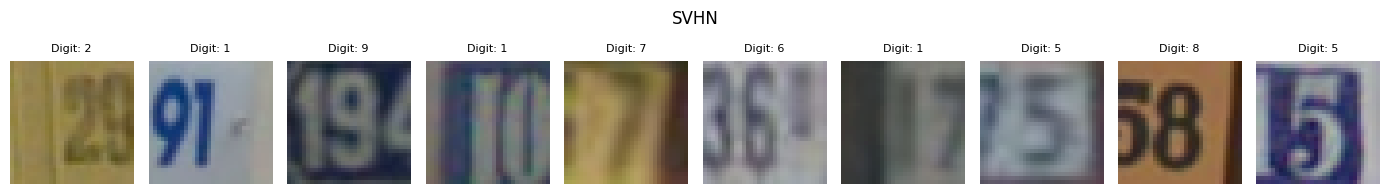

In [27]:
def denorm_svhn(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(SVHN_MEAN).view(3, 1, 1)
    std = torch.tensor(SVHN_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10, title: str = ""):
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()
    
    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_svhn(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(f"Digit: {class_names[y[i].item()]}", fontsize=8)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_images(train_loader_cnn, n=10, title="SVHN")

In [28]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)

cnn_model = SimpleCNN(num_classes=10).to(DEVICE)
print(cnn_model)
print("Trainable params:", count_params(cnn_model))

with torch.no_grad():
    test_input = torch.randn(2, 3, 32, 32).to(DEVICE)
    out = cnn_model(test_input)
    print("Input:", test_input.shape, "-> Output:", out.shape)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable params: 620362
Input: torch.Size([2, 3, 32, 32]) -> Output: torch.Size([2, 10])


In [29]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            return float("nan"), float("nan")
        loss.backward()
        optimizer.step()
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            return float("nan"), float("nan")
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        dt = time.time() - t0
        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | train loss {tr_loss:.4f}, acc {tr_acc:.3f} | val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s")
        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break
    return history

def plot_history(hist: Dict[str, List[float]], title: str = "", save_path: str = None):
    epochs = list(range(1, len(hist["train_loss"]) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, hist["train_loss"], label="train loss")
    axes[0].plot(epochs, hist["val_loss"], label="val loss")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title(title + " | loss")
    axes[0].grid(True); axes[0].legend()
    axes[1].plot(epochs, hist["train_acc"], label="train acc")
    axes[1].plot(epochs, hist["val_acc"], label="val acc")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title(title + " | accuracy")
    axes[1].grid(True); axes[1].legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


Experiment C1
Trainable params: 620362
Epoch 01/3 | train loss 2.2493, acc 0.190 | val loss 2.2321, acc 0.192 | 32.7s
Epoch 02/3 | train loss 2.2017, acc 0.204 | val loss 2.1323, acc 0.240 | 36.7s
Epoch 03/3 | train loss 1.9503, acc 0.333 | val loss 1.6926, acc 0.404 | 37.0s
Saved: artifacts\figures\c1_curves.png


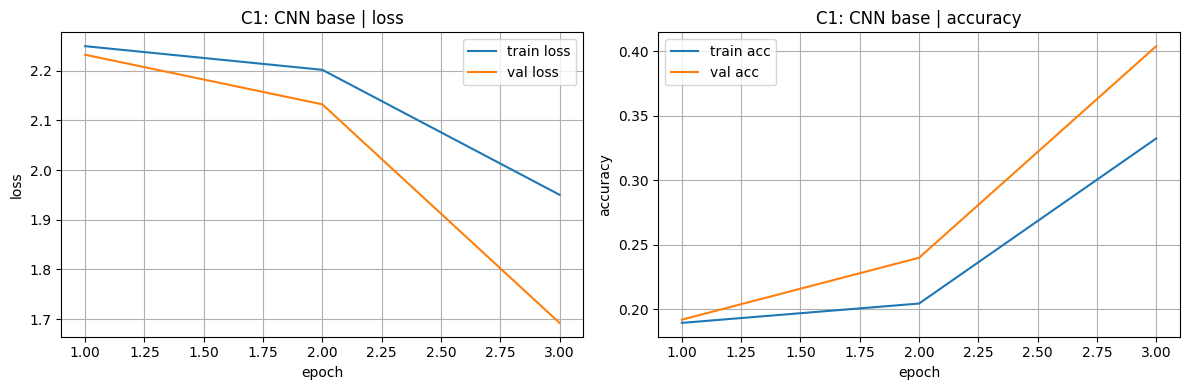


Experiment C2
Trainable params: 620362
Epoch 01/3 | train loss 2.2335, acc 0.196 | val loss 2.2417, acc 0.192 | 31.3s
Epoch 02/3 | train loss 2.2206, acc 0.204 | val loss 2.2386, acc 0.192 | 31.7s
Epoch 03/3 | train loss 2.2086, acc 0.204 | val loss 2.2346, acc 0.192 | 37.8s
Saved: artifacts\figures\c2_curves.png


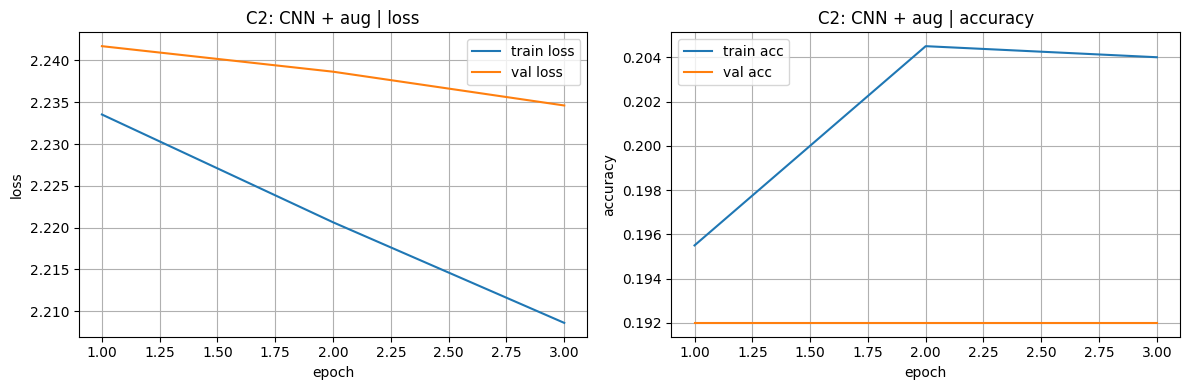

In [30]:
criterion = nn.CrossEntropyLoss()
results = []

def run_experiment_cnn(exp_id: str, train_loader, val_loader, model_fn, lr: float = 1e-3, epochs: int = EPOCHS_CNN):
    model = model_fn().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    print(f"\n{'='*80}\nExperiment {exp_id}")
    print(f"Trainable params: {count_params(model)}")
    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if hist["val_acc"] else float("nan")
    results.append({
        "experiment_id": exp_id, "task": "classification", "dataset": "SVHN",
        "seed": RANDOM_STATE, "model_summary": "SimpleCNN", "optimizer": "Adam",
        "lr": lr, "epochs_trained": len(hist["train_loss"]),
        "best_val_accuracy": best_val_acc, "test_accuracy": None,
        "precision": None, "recall": None, "mean_iou": None, "notes": ""
    })
    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}

res_c1 = run_experiment_cnn("C1", train_loader_cnn, val_loader_cnn, lambda: SimpleCNN(10))
plot_history(res_c1["history"], title="C1: CNN base", save_path=os.path.join(FIGURES_DIR, "c1_curves.png"))

res_c2 = run_experiment_cnn("C2", train_loader_aug, val_loader_cnn, lambda: SimpleCNN(10))
plot_history(res_c2["history"], title="C2: CNN + aug", save_path=os.path.join(FIGURES_DIR, "c2_curves.png"))


C3: ResNet18 HEAD-ONLY (FROZEN BACKBONE)
✓ PRETRAINED WEIGHTS: Loading ResNet18 with ResNet18_Weights.IMAGENET1K_V1
✓ PRETRAINED: Using ImageNet weights for transfer learning
✓ HEAD-ONLY MODE: Freezing backbone (all layers except fc)
✓ FROZEN: All backbone parameters frozen (requires_grad=False)
✓ HEAD-ONLY: Classifier head (fc) unfrozen for training
✓ FROZEN BACKBONE: Trainable params: 5,130 / 11,181,642 (0.05%)
✓ HEAD-ONLY: Only 5,130 parameters will be updated (fc layer)

Experiment C3: ResNet18 HEAD-ONLY (FROZEN BACKBONE)
Epoch 01/3 | train loss 2.2932, acc 0.183 | val loss 2.2482, acc 0.178 | 65.4s
Epoch 02/3 | train loss 2.0825, acc 0.261 | val loss 2.0912, acc 0.258 | 56.2s
Epoch 03/3 | train loss 1.9654, acc 0.330 | val loss 2.0396, acc 0.288 | 54.0s
Saved: artifacts\figures\c3_curves.png


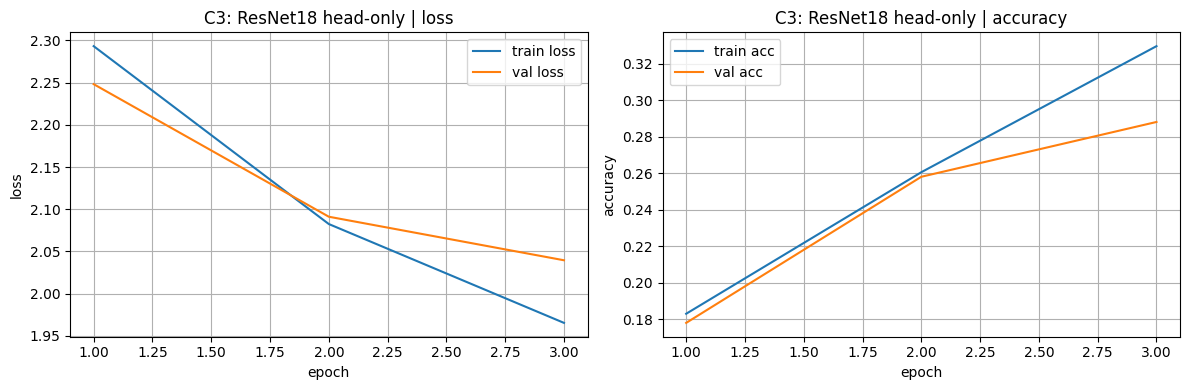


C4: ResNet18 FINE-TUNE (PARTIAL UNFREEZE)
✓ FINE-TUNING: Unfreezing layer4 (backbone) + fc (head)
✓ PARTIAL UNFREEZE: layer4 + fc will be trained
✓ FINE-TUNING: Trainable params: 8,398,858 / 11,181,642 (75.11%)

Experiment C4: ResNet18 FINE-TUNE (PARTIAL UNFREEZE)
Epoch 01/3 | train loss 1.6367, acc 0.459 | val loss 1.3602, acc 0.530 | 64.6s
Epoch 02/3 | train loss 0.7954, acc 0.772 | val loss 1.1226, acc 0.642 | 62.2s
Epoch 03/3 | train loss 0.3950, acc 0.916 | val loss 1.0434, acc 0.660 | 64.0s
Saved: artifacts\figures\c4_curves.png


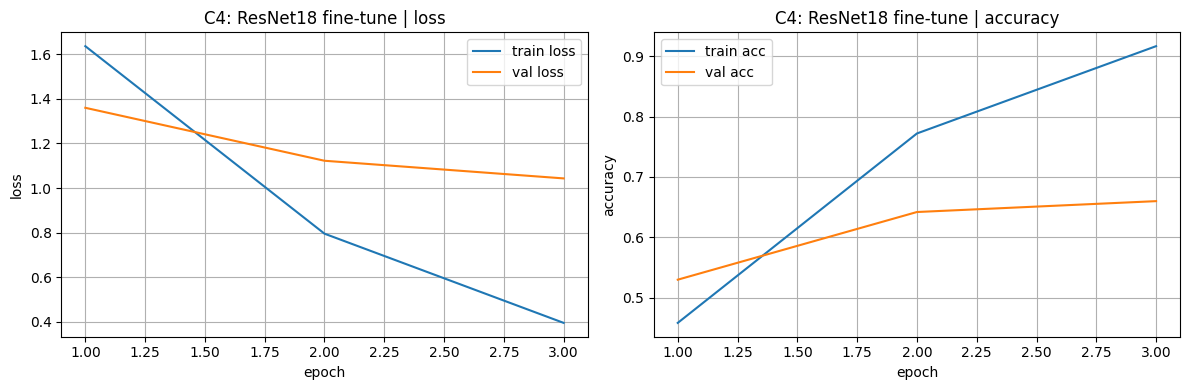

In [31]:
def build_resnet18_svhn(num_classes: int = 10, pretrained: bool = True):
    if pretrained:
        weights = ResNet18_Weights.IMAGENET1K_V1
        print(f"✓ PRETRAINED WEIGHTS: Loading ResNet18 with {weights}")
        print(f"✓ PRETRAINED: Using ImageNet weights for transfer learning")
        model = resnet18(weights=weights)
    else:
        print("✓ Loading ResNet18 with random initialization")
        model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool):
    """Включает/выключает requires_grad для всех параметров модуля"""
    for p in module.parameters():
        p.requires_grad = flag


print("\n" + "="*60)
print("C3: ResNet18 HEAD-ONLY (FROZEN BACKBONE)")
print("="*60)

model_c3 = build_resnet18_svhn(pretrained=True).to(DEVICE)

print("✓ HEAD-ONLY MODE: Freezing backbone (all layers except fc)")
set_requires_grad(model_c3, False)  # ❄️ FROZEN: заморозить ВСЁ
print("✓ FROZEN: All backbone parameters frozen (requires_grad=False)")


set_requires_grad(model_c3.fc, True)  
print("✓ HEAD-ONLY: Classifier head (fc) unfrozen for training")

trainable = sum(p.numel() for p in model_c3.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_c3.parameters())
print(f"✓ FROZEN BACKBONE: Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
print(f"✓ HEAD-ONLY: Only {trainable:,} parameters will be updated (fc layer)")

optimizer_c3 = torch.optim.Adam(model_c3.fc.parameters(), lr=1e-3)
print(f"\nExperiment C3: ResNet18 HEAD-ONLY (FROZEN BACKBONE)")
hist_c3 = fit(model_c3, train_loader_resnet, val_loader_resnet, optimizer_c3, criterion, epochs=EPOCHS_HEAD)
best_val_acc_c3 = float(np.nanmax(hist_c3["val_acc"])) if hist_c3["val_acc"] else float("nan")

results.append({
    "experiment_id": "C3", "task": "classification", "dataset": "SVHN",
    "seed": RANDOM_STATE, "model_summary": "ResNet18-head-only", "optimizer": "Adam",
    "lr": 1e-3, "epochs_trained": len(hist_c3["train_loss"]),  #  ЧИСЛО
    "best_val_accuracy": best_val_acc_c3, "test_accuracy": None,
    "precision": None, "recall": None, "mean_iou": None,
    "notes": "frozen backbone, head-only training"
})
plot_history(hist_c3, title="C3: ResNet18 head-only", save_path=os.path.join(FIGURES_DIR, "c3_curves.png"))

print("\n" + "="*60)
print("C4: ResNet18 FINE-TUNE (PARTIAL UNFREEZE)")
print("="*60)

set_requires_grad(model_c3.layer4, True)
set_requires_grad(model_c3.fc, True)
print("✓ FINE-TUNING: Unfreezing layer4 (backbone) + fc (head)")
print("✓ PARTIAL UNFREEZE: layer4 + fc will be trained")

trainable = sum(p.numel() for p in model_c3.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_c3.parameters())
print(f"✓ FINE-TUNING: Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

params = [
    {"params": model_c3.layer4.parameters(), "lr": 1e-4},
    {"params": model_c3.fc.parameters(), "lr": 1e-3},
]
optimizer_c4 = torch.optim.Adam(params, weight_decay=1e-4)

print(f"\nExperiment C4: ResNet18 FINE-TUNE (PARTIAL UNFREEZE)")
hist_c4 = fit(model_c3, train_loader_resnet, val_loader_resnet, optimizer_c4, criterion, epochs=EPOCHS_FT)
best_val_acc_c4 = float(np.nanmax(hist_c4["val_acc"])) if hist_c4["val_acc"] else float("nan")

results.append({
    "experiment_id": "C4", "task": "classification", "dataset": "SVHN",
    "seed": RANDOM_STATE, "model_summary": "ResNet18-finetune", "optimizer": "Adam",
    "lr": 1e-4, "epochs_trained": len(hist_c4["train_loss"]),  
    "best_val_accuracy": best_val_acc_c4, "test_accuracy": None,
    "precision": None, "recall": None, "mean_iou": None,
    "notes": "partial fine-tuning: layer4+fc"
})
plot_history(hist_c4, title="C4: ResNet18 fine-tune", save_path=os.path.join(FIGURES_DIR, "c4_curves.png"))

Best classification experiment: C4 | val_acc: 0.6600
Test accuracy (best model C4): 0.7140
Saved: artifacts/best_classifier.pt
Saved: artifacts/best_classifier_config.json
Saved: artifacts\figures\classification_curves_best.png


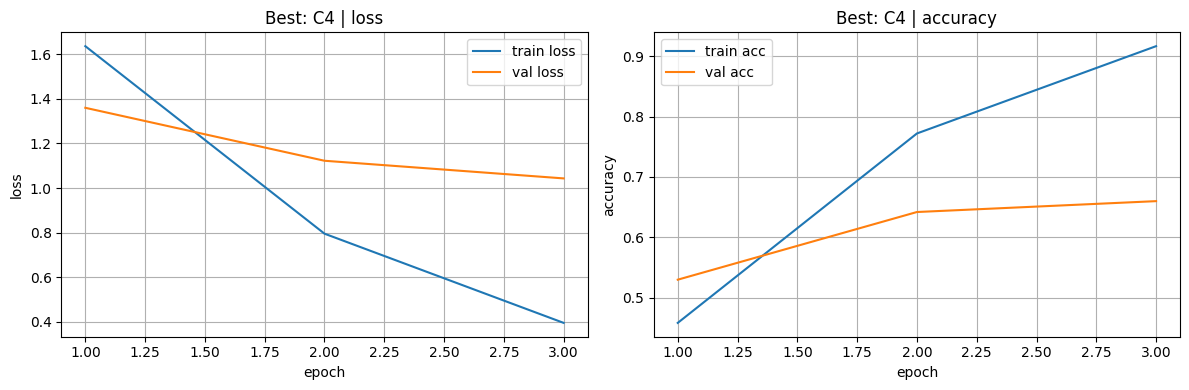

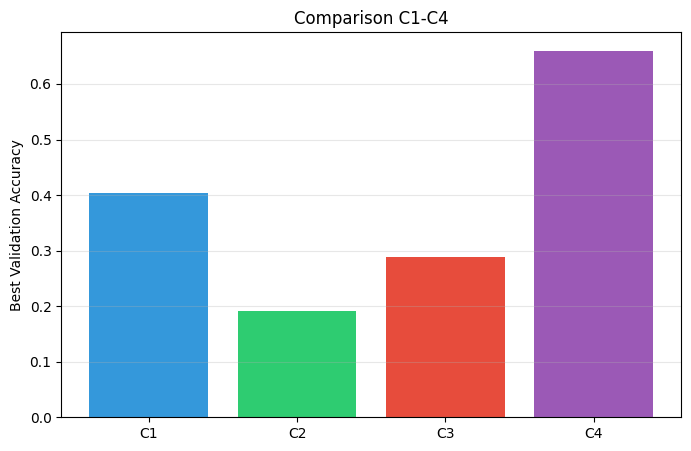

Saved: artifacts\figures/classification_compare.png


In [32]:
classification_results = [r for r in results if r["task"] == "classification"]
best_exp = max(classification_results, key=lambda x: x["best_val_accuracy"] if not math.isnan(x["best_val_accuracy"]) else -1)
best_exp_id = best_exp["experiment_id"]
print(f"Best classification experiment: {best_exp_id} | val_acc: {best_exp['best_val_accuracy']:.4f}")

@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

if best_exp_id == "C1":
    best_model, test_loader, best_hist = res_c1["model"], test_loader_cnn, res_c1["history"]
elif best_exp_id == "C2":
    best_model, test_loader, best_hist = res_c2["model"], test_loader_cnn, res_c2["history"]
elif best_exp_id in ["C3", "C4"]:
    best_model, test_loader = model_c3, test_loader_resnet
    best_hist = hist_c3 if best_exp_id == "C3" else hist_c4
else:
    raise ValueError("Unknown best experiment")

test_acc = accuracy_on_loader(best_model, test_loader)
print(f"Test accuracy (best model {best_exp_id}): {test_acc:.4f}")

for r in results:
    if r["experiment_id"] == best_exp_id:
        r["test_accuracy"] = test_acc

torch.save(best_model.state_dict(), os.path.join(ARTIFACTS_DIR, "best_classifier.pt"))
print(f"Saved: {ARTIFACTS_DIR}/best_classifier.pt")

config = {
    "dataset": "SVHN",
    "architecture": "SimpleCNN" if best_exp_id in ["C1", "C2"] else "ResNet18",
    "transforms": "basic" if best_exp_id == "C1" else "augmented" if best_exp_id == "C2" else "resnet_imagenet",
    "seed": RANDOM_STATE, "batch_size": BATCH_SIZE,
    "best_experiment": best_exp_id, "test_accuracy": test_acc
}
with open(os.path.join(ARTIFACTS_DIR, "best_classifier_config.json"), "w") as f:
    json.dump(config, f, indent=2)
print(f"Saved: {ARTIFACTS_DIR}/best_classifier_config.json")

plot_history(best_hist, title=f"Best: {best_exp_id}", save_path=os.path.join(FIGURES_DIR, "classification_curves_best.png"))

exp_ids = ["C1", "C2", "C3", "C4"]
val_accs = [r["best_val_accuracy"] for r in classification_results]
plt.figure(figsize=(8, 5))
plt.bar(exp_ids, val_accs, color=["#3498db", "#2ecc71", "#e74c3c", "#9b59b6"])
plt.ylabel("Best Validation Accuracy"); plt.title("Comparison C1-C4")
plt.grid(axis="y", alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, "classification_compare.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/classification_compare.png")

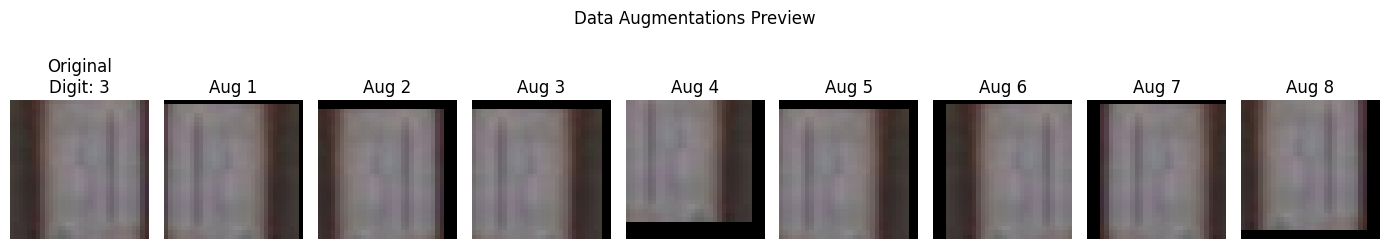

Saved: artifacts\figures/augmentations_preview.png


In [33]:
@torch.no_grad()
def show_augmentations(n: int = 8):
    max_idx = min(100, len(datasets_a["train_aug"]) - 1)
    idx = random.randint(0, max_idx)
    basic_tf = get_transforms_cnn(augment=False)
    ds_basic = torchvision.datasets.SVHN(root=DATA_DIR, split="train", download=True, transform=basic_tf)
    safe_idx = idx % len(ds_basic)
    img_basic, label = ds_basic[safe_idx]
    aug_tf = get_transforms_cnn(augment=True)
    ds_aug = torchvision.datasets.SVHN(root=DATA_DIR, split="train", download=True, transform=aug_tf)
    
    plt.figure(figsize=(14, 3))
    plt.subplot(1, n+1, 1)
    img = denorm_svhn(img_basic).clamp(0, 1).permute(1, 2, 0).numpy()
    plt.imshow(img); plt.title(f"Original\nDigit: {class_names[label]}"); plt.axis("off")
    for i in range(n):
        plt.subplot(1, n+1, i+2)
        safe_idx_aug = idx % len(ds_aug)
        img_aug, _ = ds_aug[safe_idx_aug]
        img = denorm_svhn(img_aug).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img); plt.title(f"Aug {i+1}"); plt.axis("off")
    plt.suptitle("Data Augmentations Preview"); plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "augmentations_preview.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIGURES_DIR}/augmentations_preview.png")

show_augmentations()

In [35]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

print("Loading segmentation model...")
weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=weights)
seg_model.to(DEVICE)
seg_model.eval()
print("Model loaded successfully")
DETECTION_FAST_SAMPLES = 20

def get_segmentation_transforms():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ])

def load_pet_segmentation(data_dir: str = "./data_pets"):
    tf = get_segmentation_transforms()
    ds_train = torchvision.datasets.OxfordIIITPet(
        root=data_dir, split="trainval", target_types=["segmentation"], download=True, transform=tf
    )
    ds_test = torchvision.datasets.OxfordIIITPet(
        root=data_dir, split="test", target_types=["segmentation"], download=True, transform=tf
    )
    return ds_train, ds_test

print("Loading OxfordIIITPet dataset...")
ds_pet_train, ds_pet_test = load_pet_segmentation()
print(f"Train: {len(ds_pet_train)}, Test: {len(ds_pet_test)}")

Loading segmentation model...


Model loaded successfully
Loading OxfordIIITPet dataset...


100.0%


Train: 3680, Test: 3669


In [36]:
def calculate_segmentation_iou(pred_mask, gt_mask):
    if not isinstance(pred_mask, np.ndarray):
        if hasattr(pred_mask, 'cpu'):
            pred_mask = pred_mask.cpu().numpy()
        else:
            pred_mask = np.array(pred_mask)
    
    if not isinstance(gt_mask, np.ndarray):
        if hasattr(gt_mask, 'cpu'):
            gt_mask = gt_mask.cpu().numpy()
        else:
            gt_mask = np.array(gt_mask)
    
    pred = pred_mask > 0
    gt = gt_mask > 0
    
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    
    if union == 0:
        return 0.0
    
    return intersection / union

def evaluate_segmentation(model, dataset, device, max_samples=50, postprocess_type="basic"):
    
    model.eval()
    ious = []
    
    for i in range(min(max_samples, len(dataset))):
        image, target = dataset[i]
        image_tensor = image.to(device).unsqueeze(0)
        
        with torch.no_grad():
            output = model(image_tensor)['out'][0]
        
        pred_mask = output.argmax(dim=0).cpu().numpy()  
        
        if isinstance(target, dict) and 'mask' in target:
            gt_mask_pil = target['mask']
            gt_mask = np.array(gt_mask_pil)  
        elif hasattr(target, 'squeeze'):
            gt_mask = target.squeeze().cpu().numpy()
        else:
            gt_mask = np.array(target)
        
        
        if postprocess_type == "basic":
            final_mask = pred_mask
        else:  
            final_mask = pred_mask.copy()
            unique, counts = np.unique(final_mask, return_counts=True)
            for u, c in zip(unique, counts):
                if c < 50:
                    final_mask[final_mask == u] = 0
        
        iou = calculate_segmentation_iou(final_mask, gt_mask)
        ious.append(iou)
    
    return sum(ious) / len(ious) if ious else 0.0

In [37]:
results = [r for r in results if r["experiment_id"] not in ["V1", "V2"]]



print("Evaluating V1 (basic postprocess)...")
mean_iou_v1 = evaluate_segmentation(seg_model, ds_pet_test, DEVICE, max_samples=DETECTION_FAST_SAMPLES, postprocess_type="basic")
print(f"V1 Mean IoU: {mean_iou_v1:.4f}")

print("Evaluating V2 (alternative postprocess)...")
mean_iou_v2 = evaluate_segmentation(seg_model, ds_pet_test, DEVICE, max_samples=DETECTION_FAST_SAMPLES, postprocess_type="alternative")
print(f"V2 Mean IoU: {mean_iou_v2:.4f}")

results.append({
    "experiment_id": "V1", "task": "segmentation", "dataset": "OxfordIIITPet",
    "seed": RANDOM_STATE, "model_summary": "DeepLabV3_ResNet50",
    "optimizer": "N/A (pretrained)", "lr": "", "epochs_trained": 0,  
    "best_val_accuracy": None, "test_accuracy": None,
    "precision": None, "recall": None, "mean_iou": mean_iou_v1,
    "notes": "basic postprocess (inference only)"
})

results.append({
    "experiment_id": "V2", "task": "segmentation", "dataset": "OxfordIIITPet",
    "seed": RANDOM_STATE, "model_summary": "DeepLabV3_ResNet50",
    "optimizer": "N/A (pretrained)", "lr": "", "epochs_trained": 0,  
    "best_val_accuracy": None, "test_accuracy": None,
    "precision": None, "recall": None, "mean_iou": mean_iou_v2,
    "notes": "alternative postprocess (inference only)"
})

print(f"\nResults added to results list")
print(f"Total experiments: {len(results)}")

Evaluating V1 (basic postprocess)...
V1 Mean IoU: 0.4603
Evaluating V2 (alternative postprocess)...
V2 Mean IoU: 0.4603

Results added to results list
Total experiments: 6


Saved: artifacts\figures\segmentation_examples.png


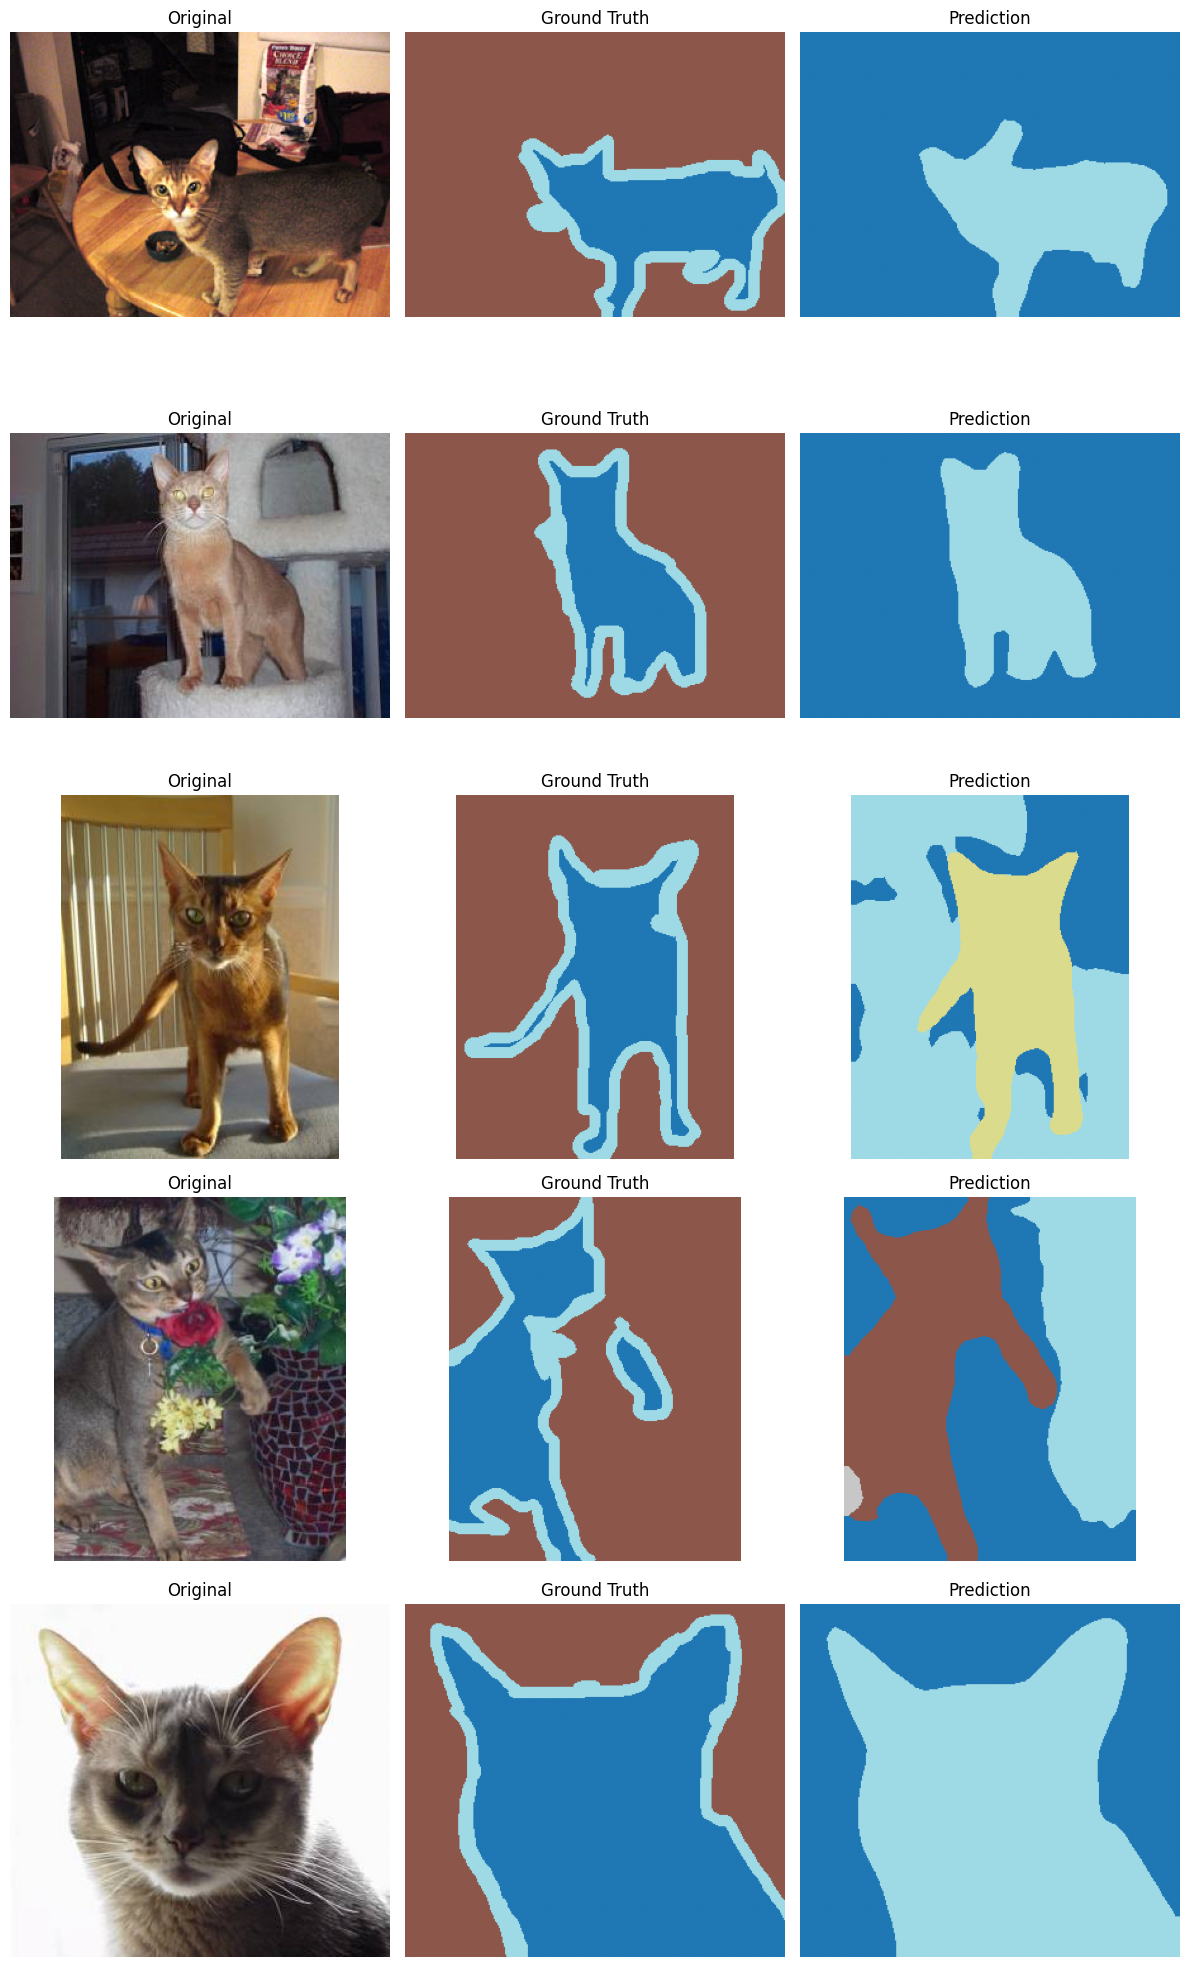

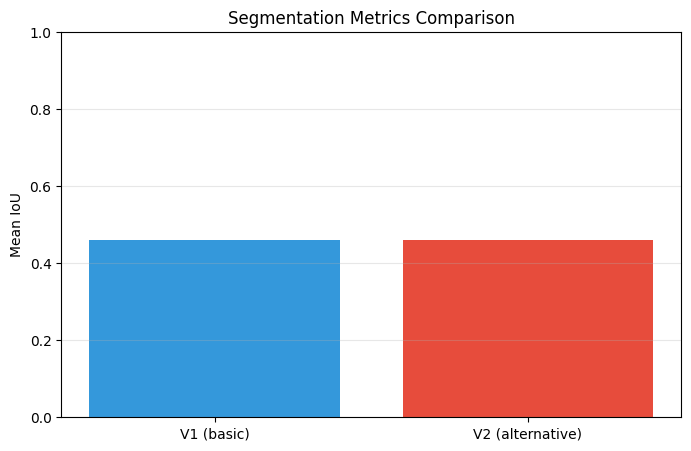

Saved: artifacts\figures/segmentation_metrics.png
Saved: artifacts/runs.csv

=== Проверка runs.csv ===
C1: 1 row(s)
C2: 1 row(s)
C3: 1 row(s)
C4: 1 row(s)
V1: 1 row(s)
V2: 1 row(s)

=== Проверка поля lr ===
C1: lr = '0.001' (type: float)
C2: lr = '0.001' (type: float)
C3: lr = '0.001' (type: float)
C4: lr = '0.0001' (type: float)
V1: lr = '' (type: str)
V2: lr = '' (type: str)

=== Все артефакты ===
artifacts/: ['best_classifier.pt', 'best_classifier_config.json', 'figures', 'runs.csv']
figures/: ['augmentations_preview.png', 'c1_curves.png', 'c2_curves.png', 'c3_curves.png', 'c4_curves.png', 'classification_compare.png', 'classification_curves_best.png', 'segmentation_examples.png', 'segmentation_metrics.png']


In [38]:
@torch.no_grad()
def visualize_segmentation(model, dataset, device, n_samples=5, save_path=None):
    model.eval()
    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
    for i in range(n_samples):
        image, target = dataset[i]
        image_tensor = image.to(device).unsqueeze(0)
        output = model(image_tensor)['out'][0]
        pred_mask = output.argmax(dim=0).cpu()
        gt_mask = torch.from_numpy(np.array(target['mask'])).long() if isinstance(target, dict) and 'mask' in target else target
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_denorm = (image * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[i][0].imshow(image_denorm); axes[i][0].set_title("Original"); axes[i][0].axis('off')
        axes[i][1].imshow(gt_mask, cmap='tab20'); axes[i][1].set_title("Ground Truth"); axes[i][1].axis('off')
        axes[i][2].imshow(pred_mask, cmap='tab20'); axes[i][2].set_title("Prediction"); axes[i][2].axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

visualize_segmentation(seg_model, ds_pet_test, DEVICE, n_samples=5, save_path=os.path.join(FIGURES_DIR, "segmentation_examples.png"))

plt.figure(figsize=(8, 5))
plt.bar(['V1 (basic)', 'V2 (alternative)'], [mean_iou_v1, mean_iou_v2], color=['#3498db', '#e74c3c'])
plt.ylabel('Mean IoU'); plt.title('Segmentation Metrics Comparison')
plt.grid(axis='y', alpha=0.3); plt.ylim(0, 1)
plt.savefig(os.path.join(FIGURES_DIR, "segmentation_metrics.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/segmentation_metrics.png")

df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(ARTIFACTS_DIR, "runs.csv"), index=False)
print(f"Saved: {ARTIFACTS_DIR}/runs.csv")

print("\n=== Проверка runs.csv ===")
for exp_id in ["C1", "C2", "C3", "C4", "V1", "V2"]:
    count = len(df_results[df_results["experiment_id"] == exp_id])
    print(f"{exp_id}: {count} row(s)")
print("\n=== Проверка поля lr ===")
for _, row in df_results.iterrows():
    print(f"{row['experiment_id']}: lr = '{row['lr']}' (type: {type(row['lr']).__name__})")

print("\n=== Все артефакты ===")
print(f"artifacts/: {os.listdir(ARTIFACTS_DIR)}")
print(f"figures/: {os.listdir(FIGURES_DIR)}")